In [ ]:
import random
import os
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# This cell is saving chekpoints to drive because the training may take alot of time and we don't want to redo everything after a crash or runtime reset.

from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/bone_age_checkpoints'
CACHE_DIR = f'{SAVE_DIR}/img_cache'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

print('Drive mounted.')
print(f'Checkpoints : {SAVE_DIR}')
print(f'Image cache : {CACHE_DIR}')

Mounted at /content/drive
Drive mounted.
Checkpoints : /content/drive/MyDrive/bone_age_checkpoints
Image cache : /content/drive/MyDrive/bone_age_checkpoints/img_cache


# Bone Age Estimation (RSNA Dataset)
**Multi-Input InceptionV3 Model (Image + Gender)**

### Pipeline Overview
1. Dataset Download & Exploration
2. Preprocessing: Object Localization → Cropping → CLAHE Enhancement
3. Validation Split
4. ImageDataGenerator + Data Augmentation
5. Multi-Input Model (InceptionV3 + Gender Branch)
6. Training

## Step 1: Install Dependencies & Download Dataset

In [ ]:
import kagglehub

# Download RSNA Bone Age dataset
kmader_rsna_bone_age_path = kagglehub.dataset_download('kmader/rsna-bone-age')
print('Data source import complete.')

import pandas as pd

# Print all available files
for dirname, _, filenames in os.walk(kmader_rsna_bone_age_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/7659.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/7212.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/15165.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/5502.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/8803.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/14766.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/4755.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/1892.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/10761.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/8734.png
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-datase

## Step 2: Load & Explore the Dataset

In [ ]:
#This cell explores the dataset structure and ensures that there are no missing values or unexpected types

import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_PATH = kmader_rsna_bone_age_path
TRAIN_CSV = os.path.join(BASE_PATH, 'boneage-training-dataset.csv')
TRAIN_IMGS = os.path.join(BASE_PATH, 'boneage-training-dataset', 'boneage-training-dataset')

# Load CSV
df = pd.read_csv(TRAIN_CSV)
print('Shape:', df.shape)
print(df.head())
print('Column dtypes:')
print(df.dtypes)
print('Null values:')
print(df.isnull().sum())

Shape: (12611, 3)
     id  boneage   male
0  1377      180  False
1  1378       12  False
2  1379       94  False
3  1380      120   True
4  1381       82  False
Column dtypes:
id         int64
boneage    int64
male        bool
dtype: object
Null values:
id         0
boneage    0
male       0
dtype: int64


In [ ]:
# Standardise columns and prepares the data for training and makes sure only valid images are used.
df.columns = [c.strip().lower() for c in df.columns]  # Removes spaces and makes the column names small letters.
print('Columns after normalisation:', df.columns.tolist()) # Prints the columns names after cleaning them.

# Creates new column containing the full file path for each X-ray image.
df['img_path'] = df['id'].astype(str).apply(
    lambda x: os.path.join(TRAIN_IMGS, x + '.png')
)

# Checks if the file is located on the local disk or not.
df['exists'] = df['img_path'].apply(os.path.exists)
print(f"Images found: {df['exists'].sum()} of {len(df)}")
df = df[df['exists']].reset_index(drop=True) # Filters out unlocated X-ray images.

# Gender as integer: male=1, female=0.
df['gender'] = df['male'].astype(int)

print('Dataset summary:')
print(f"Total samples: {len(df)}")
print(f"Male: {df['gender'].sum()}")
print(f"Female: {(df['gender'] == 0).sum()}")
print(f"Bone age range: {df['boneage'].min()} to {df['boneage'].max()} months")
print(f"Mean bone age : {df['boneage'].mean():.1f} months")

Columns after normalisation: ['id', 'boneage', 'male']
Images found: 12611 of 12611
Dataset summary:
Total samples: 12611
Male: 6833
Female: 5778
Bone age range: 1 to 228 months
Mean bone age : 127.3 months


## Step 3: Preprocessing Pipeline
### 3.1 Object Localisation → Cropping → CLAHE Enhancement

In [ ]:
import cv2
from tensorflow.keras.applications.inception_v3 import preprocess_input

def localise_and_crop(img_gray):  # Defines a function that takes gray scale image.
    """
    Object localisation via Otsu thresholding + contour detection.
    Uses asymmetric padding: more space at the top to preserve fingertips.
    Falls back to the full image if detection fails.
    """
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0) # Applies gaussian blur to smooth the image and remove the noise.

    _, binary = cv2.threshold(blurred, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU) # The core step for object detection. The otsu's threshold finds the optimal threshold.
                                                                   # It looks at histogram of pixel intensities and chooses the value that maximizes the separation from background and the hand.
                                                                   # The binary threshold means if the value is greater than the threshold then make it white, black otherwise.

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15)) # This creates a 15x15 matrix that slides over the image to modify pixels.
                                                                  # cv2.MORPH_RECT: defines kernel rectangular shape.

    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel) # Performs closing which fills small holes and connects nearby bright regions.

    contours, _ = cv2.findContours(cleaned,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE) # cv2.RETR_EXTERNAL: identifies the edges of the hand, ignoring holes, noise inside the hand.
                                                            # cv2.CHAIN_APPROX_SIMPLE: keeps only the essential coordinates needed to define the shape.

    if not contours:
        return img_gray

    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest) # Gets the bounding rectangle around that contour

    H, W = img_gray.shape

    # Asymmetric padding:
    # - Top: 15% extra to never cut fingertips
    # - Bottom: 10% for wrist context
    # - Left/Right: 8% for thumb and pinky
    pad_top = int(0.15 * h)
    pad_bottom = int(0.10 * h)
    pad_left = int(0.08 * w)
    pad_right = int(0.08 * w)

    x1 = max(x - pad_left, 0) # Move the left edge further left.
    y1 = max(y - pad_top, 0) # Move the top edge further up.
    x2 = min(x + w + pad_right, W) # Add the width to get to the right edge, then add the padding to go further right.
    y2 = min(y + h + pad_bottom, H) # Moves the bottom edge down past the wrist context.

    crop = img_gray[y1:y2, x1:x2] # Extracts the cropped hand region.
    return crop if crop.size > 0 else img_gray


def apply_clahe(img_gray, clip_limit=3, tile_grid=(8, 8)):
    """
    Apply Contrast Limited Adaptive Histogram Equalisation (CLAHE).
    Enhances local contrast without over-amplifying noise.
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    return clahe.apply(img_gray)


def apply_gaussian_blur(img_gray, kernel_size=(8, 8), sigma=0):
    """
    Apply light Gaussian blur after CLAHE
    to reduce amplified local noise.
    """
    return cv2.GaussianBlur(img_gray, kernel_size, sigma)


def preprocess_image(img_path, target_size=(299, 299)):
    """Full preprocessing pipeline:
      1. Load as grayscale
      2. Object localisation + crop
      3. CLAHE contrast enhancement
      4. Resize to target_size
      5. Convert to 3-channel
      6. Normalise to [0, 1]   Returns a float32 array of shape (H, W, 3).
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        # Return a blank image if loading fails
        return np.zeros((*target_size, 3), dtype=np.float32)

    # 1. Localise and crop the hand region
    img = localise_and_crop(img)

    # 2. CLAHE enhancement
    img = apply_clahe(img)

    # 3. Light smoothing after CLAHE
    img = apply_gaussian_blur(img, kernel_size=(3, 3), sigma=0)

    # 4. Resize
    img = cv2.resize(img, target_size)

    # 5. Convert to 3-channel by stacking
    img = cv2.merge([img, img, img])

    # 6. Normalise
    img = img.astype(np.float32)
    img = preprocess_input(img)

    return img


print('Preprocessing functions defined.')

Preprocessing functions defined.


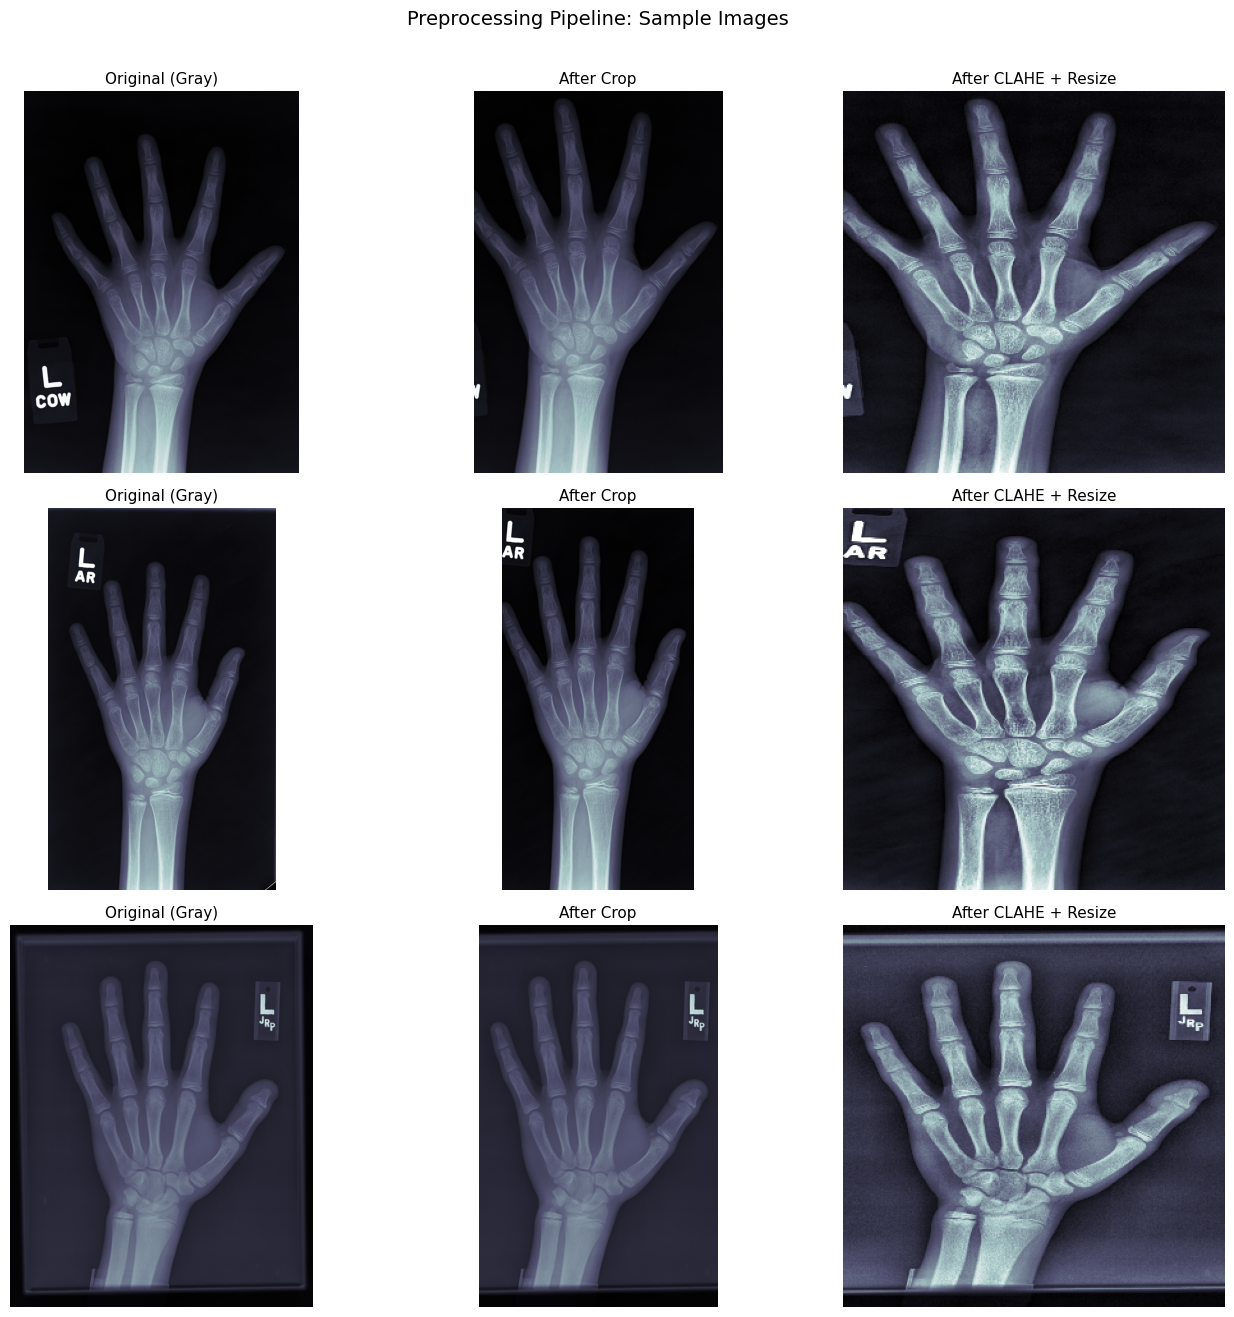

In [ ]:
import matplotlib.pyplot as plt

# Show preprocessing stages for 3 random samples
sample_paths = df['img_path'].sample(3, random_state=42).tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
stage_titles = ['Original (Gray)', 'After Crop', 'After CLAHE + Resize']

for row, path in enumerate(sample_paths):
    raw = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    crop = localise_and_crop(raw)
    enhanced = apply_clahe(crop)
    final = cv2.resize(enhanced, (299, 299))

    for col, (img, title) in enumerate(zip(
            [raw, crop, final], stage_titles)):
        axes[row, col].imshow(img, cmap='bone')
        axes[row, col].set_title(title, fontsize=11)
        axes[row, col].axis('off')

plt.suptitle('Preprocessing Pipeline: Sample Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Step 4: Train / Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

# 80 % train and 20 % validation, stratified by gender to keep gender balance
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['gender']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'Train set: {len(train_df):>5} samples '
      f'| Male: {train_df["gender"].sum()}  Female: {(train_df["gender"]==0).sum()}')
print(f'Val set: {len(val_df):>5} samples '
      f'| Male: {val_df["gender"].sum()}  Female: {(val_df["gender"]==0).sum()}')

Train set: 10088 samples | Male: 5466  Female: 4622
Val set:  2523 samples | Male: 1367  Female: 1156


In [ ]:
# Label Normalisation (z-score), we normalize the bone age so the model learns faster, more stable and more accurately.
# Compute mean/std from TRAINING set only
BONEAGE_MEAN = train_df['boneage'].mean()
BONEAGE_STD = train_df['boneage'].std()

train_df['boneage_norm'] = (train_df['boneage'] - BONEAGE_MEAN) / BONEAGE_STD
val_df['boneage_norm'] = (val_df['boneage'] - BONEAGE_MEAN) / BONEAGE_STD

print(f'Bone age mean : {BONEAGE_MEAN:.2f} months')
print(f'Bone age std : {BONEAGE_STD:.2f} months')
print(f'Normalised range : {train_df["boneage_norm"].min():.2f} to {train_df["boneage_norm"].max():.2f}')

Bone age mean : 127.30 months
Bone age std : 41.05 months
Normalised range : -3.08 to 2.45


In [ ]:
import pickle
from tqdm.auto import tqdm

TARGET_SIZE = (299, 299)


def build_disk_cache(dataframe, target_size=TARGET_SIZE, cache_dir=CACHE_DIR):
    """
    Preprocess each image once and save it as an individual .npy file on disk.
    On subsequent runs it skips already cached files.
    Uses virtually zero RAM, images are loaded per-batch during training.
    """
    missing = [
        row for _, row in dataframe.iterrows()
        if not os.path.exists(os.path.join(cache_dir, f"{row['id']}.npy"))
    ]

    if not missing:
        print(f'All {len(dataframe)} images already cached in {cache_dir}/')
        return

    print(f'Caching {len(missing)} images to disk')
    for row in tqdm(missing):
        img = preprocess_image(row['img_path'], target_size)
        np.save(os.path.join(cache_dir, f"{row['id']}.npy"), img)

    print(f'Done. Cached to {cache_dir}/')

build_disk_cache(df)

Caching 12611 images to disk


  0%|          | 0/12611 [00:00<?, ?it/s]

Done. Cached to /content/drive/MyDrive/bone_age_checkpoints/img_cache/


## Step 5: Custom Data Generator (Image + Gender → Bone Age)
Keras Sequence based generator that:
- Applies the full preprocessing pipeline on-the-fly
- Performs data augmentation on training batches
- Yields (image_batch, gender_batch) as multi-input tensors

In [ ]:
#This cell helps with memory management, it only keeps 32 images at a time in RAM and supports multi input and speed.

from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_AUGMENTATION = dict(
    rotation_range = 20, # Rotate images upto 20 degrees.
    horizontal_flip = False, # Don't flip left-right.
    zoom_range = 0.15, # Zoom in/out up to 15% helps DenseNet generalise to different hand sizes.
    width_shift_range = 0.08, # Shift image horizontally up to 8% handles off-center X-rays.
    height_shift_range = 0.08, # Shift image vertically up to 8% handles off-center X-rays.
    fill_mode = 'constant', # Fill new pixels with a constant value.
    cval = 0 # Use the black for the fill value.
)

train_aug = ImageDataGenerator(**TRAIN_AUGMENTATION)
val_aug = ImageDataGenerator()


class BoneAgeSequence(Sequence):
    """
    Multi-input Keras Sequence generator.
    Loads preprocessed .npy files from disk per batch.
    Yields: ((img_batch, gender_batch), label_batch)
    """
    def __init__(self, dataframe, batch_size=32, cache_dir=CACHE_DIR,
                 augmentor=None, shuffle=True , seed = 42):
        self.df = dataframe.copy()
        self.batch_size = batch_size
        self.cache_dir = cache_dir
        self.augmentor = augmentor
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.seed = seed
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size)) # Steps in one epoch.

    def __getitem__(self, idx):
        # Figure out which rows of the dataframe belongs to this batch.
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_rows = self.df.iloc[batch_idx]

        imgs, genders, labels = [], [], []
        for _, row in batch_rows.iterrows():
            # Load single .npy file: only 1 image in RAM at a time.
            img = np.load(os.path.join(self.cache_dir, f"{row['id']}.npy"))

            # Apply the random flip.
            if self.augmentor is not None:
                img = self.augmentor.random_transform(img)
            imgs.append(img)
            genders.append([row['gender']])
            labels.append(row['boneage_norm'])

        return (
            (np.array(imgs, dtype=np.float32),
             np.array(genders, dtype=np.float32)),
            np.array(labels, dtype=np.float32)
        )

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


BATCH_SIZE = 32

train_gen = BoneAgeSequence(train_df, batch_size=BATCH_SIZE,
                            augmentor=train_aug, shuffle=True , seed = SEED)  # Uses augmentation and shuffling which is critical for training.
val_gen = BoneAgeSequence(val_df, batch_size=BATCH_SIZE,
                            augmentor=None, shuffle=False, seed = SEED) # No augmentation or shuffling for fair evaluation.

print(f'Train batches : {len(train_gen)}')
print(f'Val batches : {len(val_gen)}')

(img_b, gen_b), lbl_b = train_gen[0]
print(f'Batch shapes → img: {img_b.shape}, gender: {gen_b.shape}, labels: {lbl_b.shape}')

Train batches : 316
Val batches : 79
Batch shapes → img: (32, 299, 299, 3), gender: (32, 1), labels: (32,)


## Step 6: Multi-Input InceptionV3 Model
**Architecture:**
- **Image branch**: InceptionV3 pretrained on ImageNet → GlobalAveragePooling → Dense
- **Gender branch**: Single neuron input → Dense(64) → Dense(32)
- **Merge**: Concatenate → Dense layers → Single regression output (months)

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D,
    Concatenate, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ( ReduceLROnPlateau, EarlyStopping, ModelCheckpoint )

IMG_SHAPE = (*TARGET_SIZE, 3)

def build_bone_age_inceptionv3(img_shape=IMG_SHAPE):
    img_input = Input(shape=img_shape, name='image_input')

    base_model = InceptionV3(
        include_top=False,
        weights='imagenet',
        input_tensor=img_input
    )

    base_model.trainable = False

    x = GlobalAveragePooling2D(name='gap')(base_model.output)
    x = Dense(512, activation='relu', name='img_dense1')(x)
    x = BatchNormalization(name='img_bn1')(x)
    x = Dropout(0.4, name='img_drop1')(x)

    x = Dense(256, activation='relu', name='img_dense2')(x)
    x = BatchNormalization(name='img_bn2')(x)
    x = Dropout(0.3, name='img_drop2')(x)

    gender_input = Input(shape=(1,), name='gender_input')
    g = Dense(64, activation='relu', name='gen_dense1')(gender_input)
    g = Dense(32, activation='relu', name='gen_dense2')(g)

    merged = Concatenate(name='merge')([x, g])
    merged = Dense(256, activation='relu', name='merged_dense1')(merged)
    merged = BatchNormalization(name='merged_bn')(merged)
    merged = Dropout(0.3, name='merged_drop')(merged)

    merged = Dense(128, activation='relu', name='merged_dense2')(merged)

    output = Dense(1, activation='linear', name='bone_age_output')(merged)

    return Model(
        inputs=[img_input, gender_input],
        outputs=output,
        name='BoneAge_InceptionV3_MultiInput'
    ), base_model


def make_mae_in_months(boneage_std):
    def mae_in_months(y_true, y_pred):
        return tf.reduce_mean(tf.abs(y_true - y_pred)) * boneage_std
    mae_in_months.__name__ = 'mae_in_months'
    return mae_in_months


mae_in_months = make_mae_in_months(BONEAGE_STD)

model, base_model = build_bone_age_inceptionv3()

model.summary()
print(f'\nTrainable parameters: {sum(p.numpy().size for p in model.trainable_weights):,}')

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "BoneAge_InceptionV3_MultiInput"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,096,513 (88.11 MB)

 Trainable params: 1,291,681 (4.93 MB)

 Non-trainable params: 21,804,832 (83.18 MB)


Trainable parameters: 1,291,681


## Step 7: Train the Model
### Phase 1 Head Training


In [ ]:
IMG_SHAPE = (*TARGET_SIZE, 3)

# This tells TensorFlow what will the generator yield.
OUTPUT_SIG = (
    (
        tf.TensorSpec(shape=(None, *IMG_SHAPE), dtype=tf.float32), # Tuple of two inputs: 1- image with batch shape.
        tf.TensorSpec(shape=(None, 1), dtype=tf.float32), # 2- gender batch with shape.
    ),
    tf.TensorSpec(shape=(None,), dtype=tf.float32), # Label batch with shape.
)

def seq_to_dataset(sequence):
    def generator():
        for i in range(len(sequence)):
            yield sequence[i]
    return tf.data.Dataset.from_generator(generator, output_signature=OUTPUT_SIG)

train_dataset = seq_to_dataset(train_gen).prefetch(tf.data.AUTOTUNE)
val_dataset = seq_to_dataset(val_gen).prefetch(tf.data.AUTOTUNE)
print('tf.data.Dataset pipelines ready.')

# PHASE 1: Head warm-up
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=mae_in_months,
    metrics=[]
)

checkpoint_path_head = f'{SAVE_DIR}/best_head_InceptionV3.keras'

callbacks_phase1 = [
    ModelCheckpoint(
        filepath=checkpoint_path_head,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )
]

print('Phase 1: head training InceptionV3')

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks_phase1,
    verbose=1
)

best_mae_phase1 = min(history_phase1.history['val_loss'])
print(f'Best Phase 1 Val MAE: {best_mae_phase1:.2f} months')

tf.data.Dataset pipelines ready.
Phase 1: head training InceptionV3
Epoch 1/50
    316/Unknown 382s 1s/step - loss: 32.6734
Epoch 1: val_loss improved from None to 21.18603, saving model to /content/drive/MyDrive/bone_age_checkpoints/best_head_InceptionV3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/bone_age_checkpoints/best_head_InceptionV3.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 425s 1s/step - loss: 28.1256 - val_loss: 21.1860 - learning_rate: 0.0010
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 21.5447
Epoch 2: val_loss improved from 21.18603 to 16.20582, saving model to /content/drive/MyDrive/bone_age_checkpoints/best_head_InceptionV3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/bone_age_checkpoints/best_head_InceptionV3.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 416s 1s/step - loss: 20.7447 - val_loss: 16.2058 - learning_rate: 0.0010
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 18.1746
Epoch 3: val_loss improved from 16.20582 to 

KeyboardInterrupt: 

### Phase 2 Fine-tuning


In [ ]:
# Load previous best checkpoint (head training)
model.load_weights(checkpoint_path_head)

# PHASE 2: fine-tuning
# Fully unfreeze the entire base model
for layer in base_model.layers:
    layer.trainable = True

# Compile with a smaller learning rate for full fine-tuning
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss=mae_in_months,
    metrics=[]
)


checkpoint_path_ft = f'{SAVE_DIR}/best_InceptionV3_finetuned.keras'

callbacks_phase2 = [
    ModelCheckpoint(
        filepath=checkpoint_path_ft,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )
]

print('Phase 2: fine-tuning InceptionV3')

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=callbacks_phase2,
    verbose=1
)

best_mae = min(history_phase2.history['val_loss'])
print(f'Best Val MAE: {best_mae:.2f} months')

Phase 2: fine-tuning InceptionV3
Epoch 1/25
    316/Unknown 579s 2s/step - loss: 17.2325
Epoch 1: val_loss improved from None to 12.57381, saving model to /content/drive/MyDrive/bone_age_checkpoints/best_InceptionV3_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/bone_age_checkpoints/best_InceptionV3_finetuned.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - loss: 14.5823 - val_loss: 12.5738 - learning_rate: 3.0000e-05
Epoch 2/25
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 12.3304
Epoch 2: val_loss improved from 12.57381 to 10.47097, saving model to /content/drive/MyDrive/bone_age_checkpoints/best_InceptionV3_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/bone_age_checkpoints/best_InceptionV3_finetuned.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 575s 2s/step - loss: 12.0202 - val_loss: 10.4710 - learning_rate: 3.0000e-05
Epoch 3/25
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 11.4055
Epoch 3: val_loss improved from 10.47097 to 10.3750

In [ ]:
# Save best weights to Drive permanently
best_weights_path = f'{SAVE_DIR}/best_InceptionV3_finetuned.keras'
final_model_path = f'{SAVE_DIR}/bone_age_InceptionV3_8_8_months.keras'

import shutil
# Copy best checkpoint with a descriptive name
shutil.copy(best_weights_path, final_model_path)
print(f'Best weights saved to: {final_model_path}')

Best weights saved to: /content/drive/MyDrive/bone_age_checkpoints/bone_age_InceptionV3_8_8_months.keras


In [ ]:
# Save full model, can be loaded later without rebuilding architecture.
model.load_weights(best_weights_path)   # Make sure best weights are loaded.
model.save(final_model_path)
print(f'Full model saved to: {final_model_path}')
print(f'Val MAE: {float(best_mae):.1f} months')

Full model saved to: /content/drive/MyDrive/bone_age_checkpoints/bone_age_InceptionV3_8_8_months.keras
Val MAE: 8.8 months


In [ ]:
# This cell saves normalization statistics because they are needed later when we want to reverse normalization or make predictions on new data.
import json

stats = {
    'BONEAGE_MEAN' : float(BONEAGE_MEAN),
    'BONEAGE_STD' : float(BONEAGE_STD),
    'best_val_mae' : float(best_mae)
}

stats_path = f'{SAVE_DIR}/normalisation_stats.json'
with open(stats_path, 'w') as f:
    json.dump(stats, f, indent=2)

print(f'Normalisation stats saved to: {stats_path}')
print(f'BONEAGE_MEAN : {BONEAGE_MEAN:.2f}')
print(f'BONEAGE_STD : {BONEAGE_STD:.2f}')

Normalisation stats saved to: /content/drive/MyDrive/bone_age_checkpoints/normalisation_stats.json
BONEAGE_MEAN : 127.30
BONEAGE_STD : 41.05


In [ ]:
folder_path = '/content/drive/MyDrive/bone_age_checkpoints/img_cache'
shutil.rmtree(folder_path)

## Step 9: Save the Model

In [ ]:
# Save full model to Google Drive
final_model_path = f'{SAVE_DIR}/bone_age_InceptionV3_final_8_8_MAE.keras'
model.save(final_model_path)
print(f'Model saved to {final_model_path}')

# Also download a local copy
try:
    from google.colab import files
    files.download(final_model_path)
    print('Download started.')
except Exception:
    print('Not running in Colab skipping download step.')

Model saved to /content/drive/MyDrive/bone_age_checkpoints/bone_age_InceptionV3_final_8_8_MAE.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
